In [1]:
import matplotlib
print(matplotlib.__version__)


3.10.0


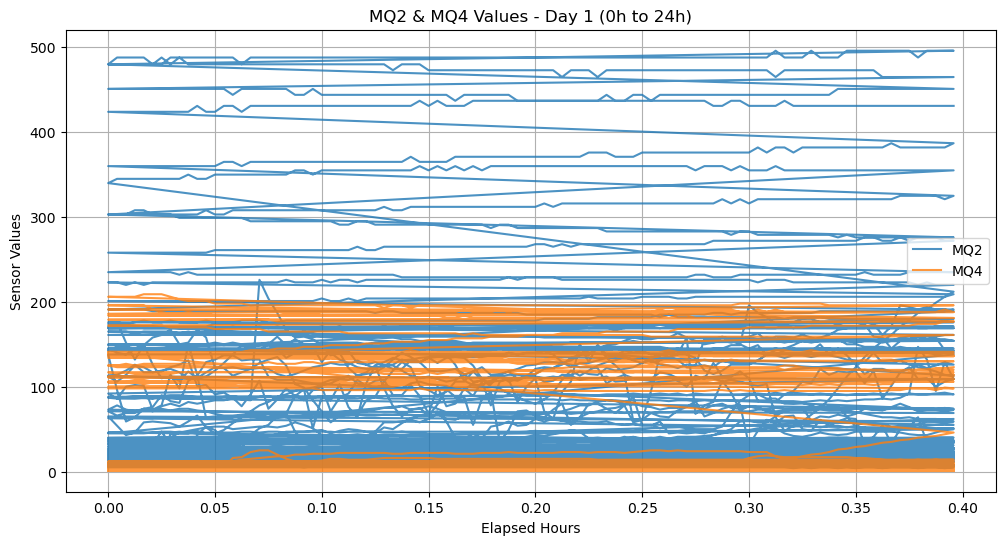

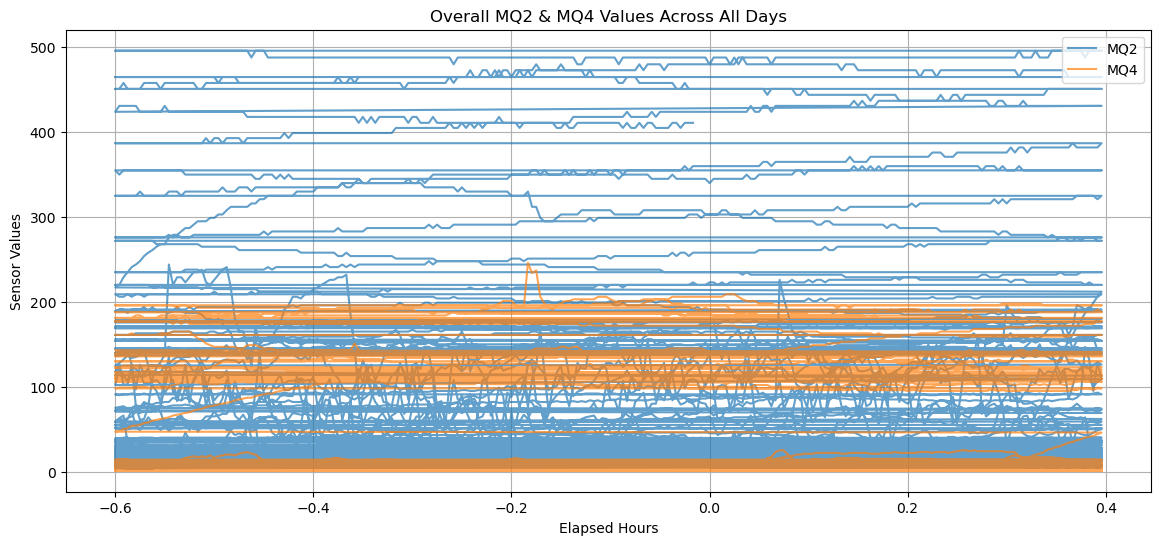

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File path
file_path = r"D:\ChipVista\Projects\decaying fruits\DATALOG-1.csv"

# Load dataset
df = pd.read_csv(file_path)

# Keep only useful columns
df = df[['mq2', 'mq4', 'Time']]

# Convert Time into seconds
def parse_time(t):
    try:
        mins, sec_milli = t.split(":")
        mins = int(mins)
        sec = float(sec_milli)
        total_seconds = mins * 60 + sec
        return total_seconds
    except:
        return None

df['TotalSeconds'] = df['Time'].apply(parse_time)
df = df.dropna(subset=['TotalSeconds']).reset_index(drop=True)

# Convert into hours and shift start to 0
df['TotalHours'] = df['TotalSeconds'] / 3600.0
df['ElapsedHours'] = df['TotalHours'] - df['TotalHours'].iloc[0]

# Number of 24-hour periods
num_days = int(np.ceil(df['ElapsedHours'].max() / 24))

# Plot per 24-hour day
for day in range(num_days):
    start = day * 24
    end = (day + 1) * 24
    subset = df[(df['ElapsedHours'] >= start) & (df['ElapsedHours'] < end)]
    
    plt.figure(figsize=(12, 6))
    plt.plot(subset['ElapsedHours'], subset['mq2'], label='MQ2', alpha=0.8)
    plt.plot(subset['ElapsedHours'], subset['mq4'], label='MQ4', alpha=0.8)
    plt.title(f"MQ2 & MQ4 Values - Day {day+1} ({start}h to {end}h)")
    plt.xlabel("Elapsed Hours")
    plt.ylabel("Sensor Values")
    plt.legend()
    plt.grid(True)
    plt.show()

# Overall graph
plt.figure(figsize=(14, 6))
plt.plot(df['ElapsedHours'], df['mq2'], label='MQ2', alpha=0.7)
plt.plot(df['ElapsedHours'], df['mq4'], label='MQ4', alpha=0.7)
plt.title("Overall MQ2 & MQ4 Values Across All Days")
plt.xlabel("Elapsed Hours")
plt.ylabel("Sensor Values")
plt.legend()
plt.grid(True)
plt.show()


C:\Users\mbila\AppData\Local\Temp\ipykernel_28944\1434863366.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['HourOfDay'] = subset['HourIndex'] - start


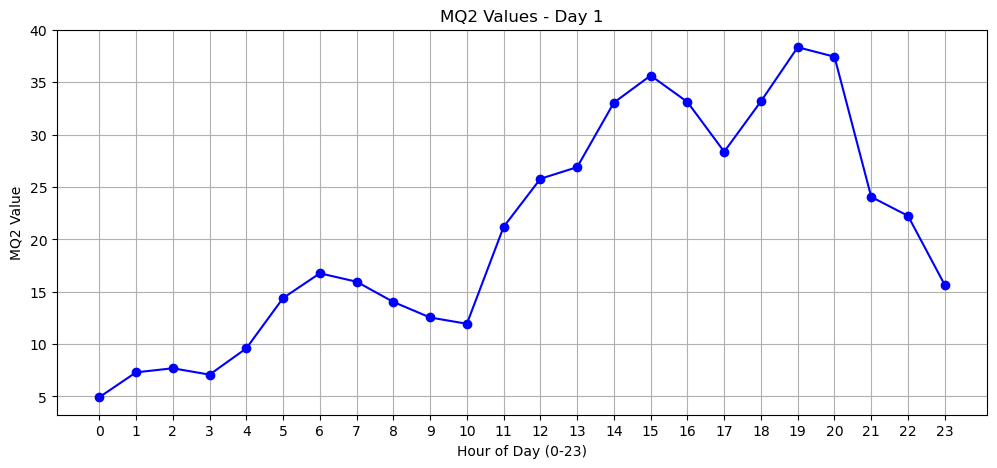

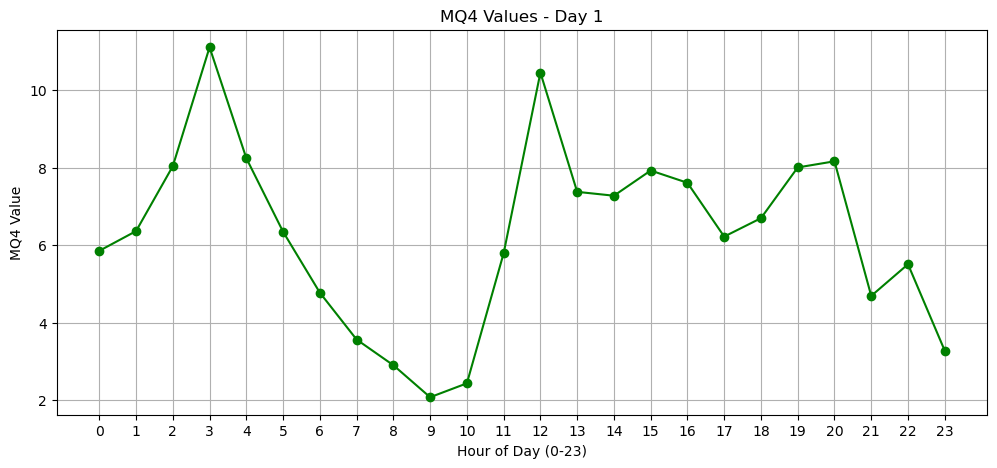

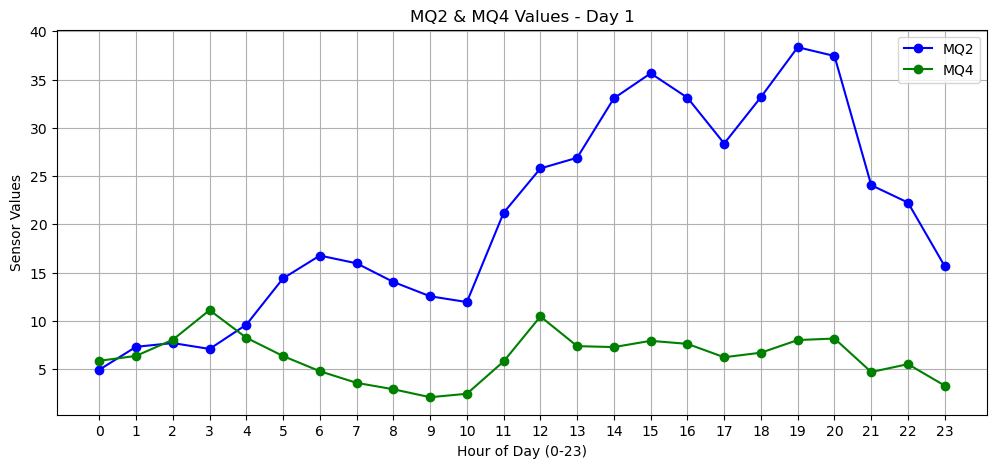

C:\Users\mbila\AppData\Local\Temp\ipykernel_28944\1434863366.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['HourOfDay'] = subset['HourIndex'] - start


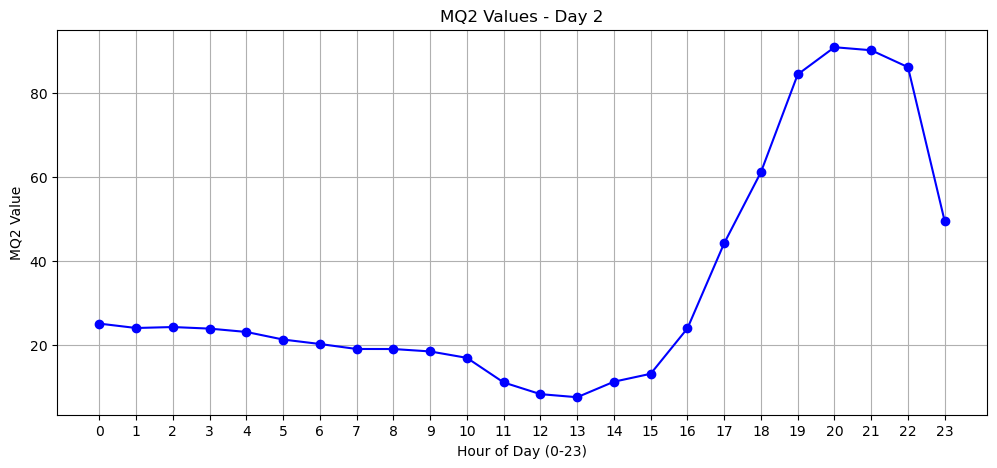

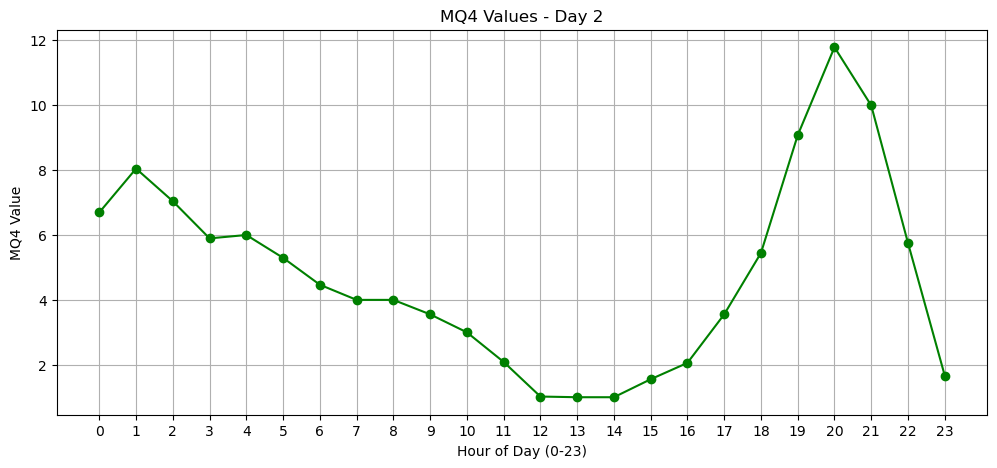

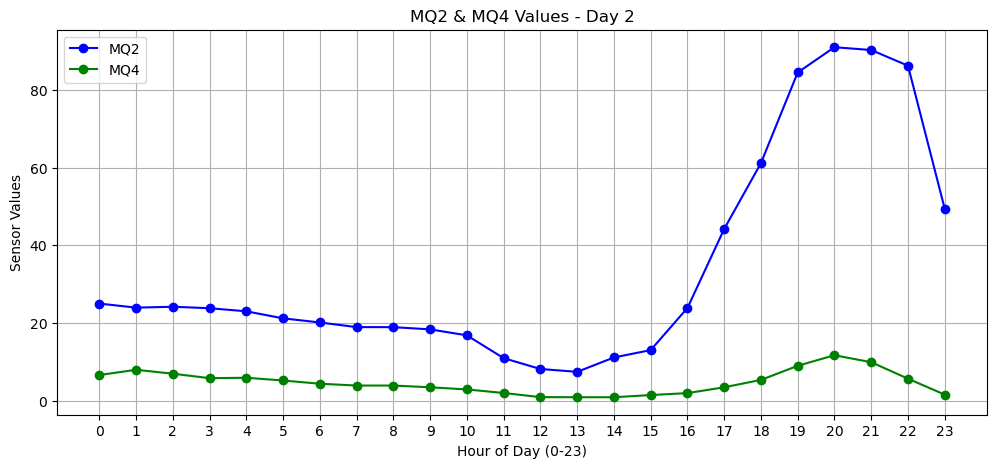

C:\Users\mbila\AppData\Local\Temp\ipykernel_28944\1434863366.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['HourOfDay'] = subset['HourIndex'] - start


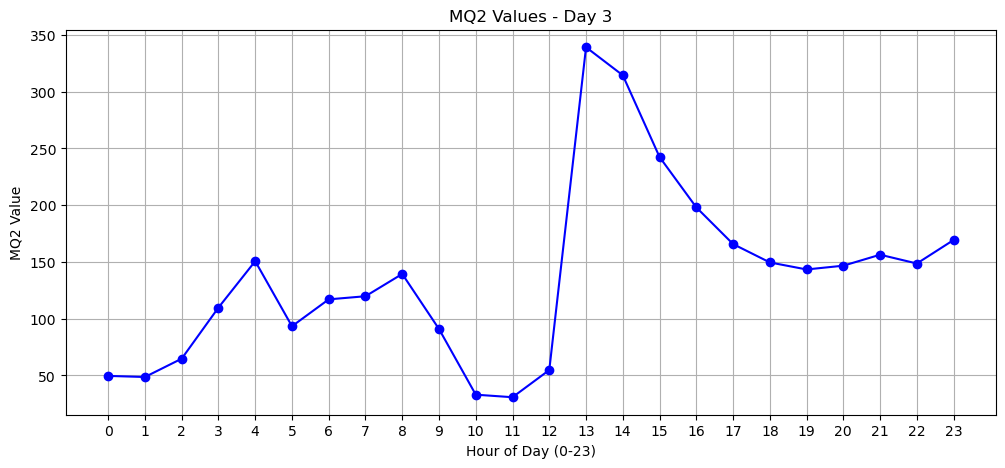

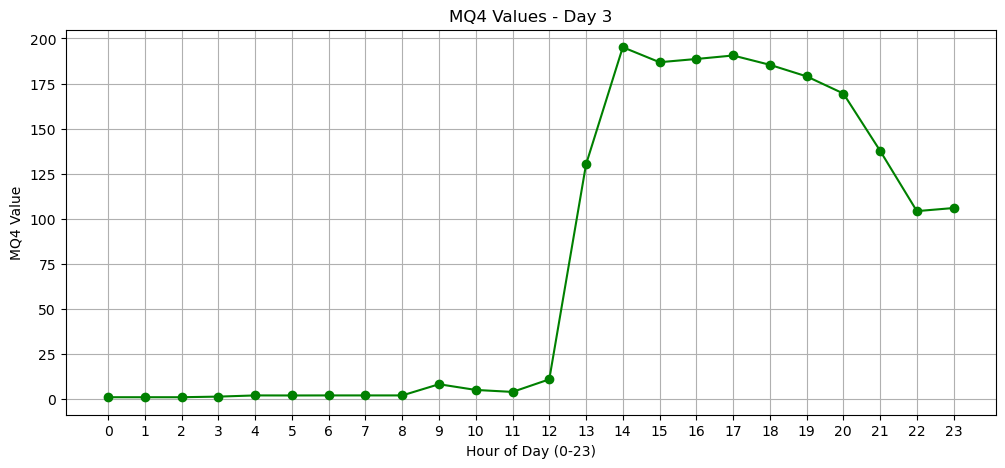

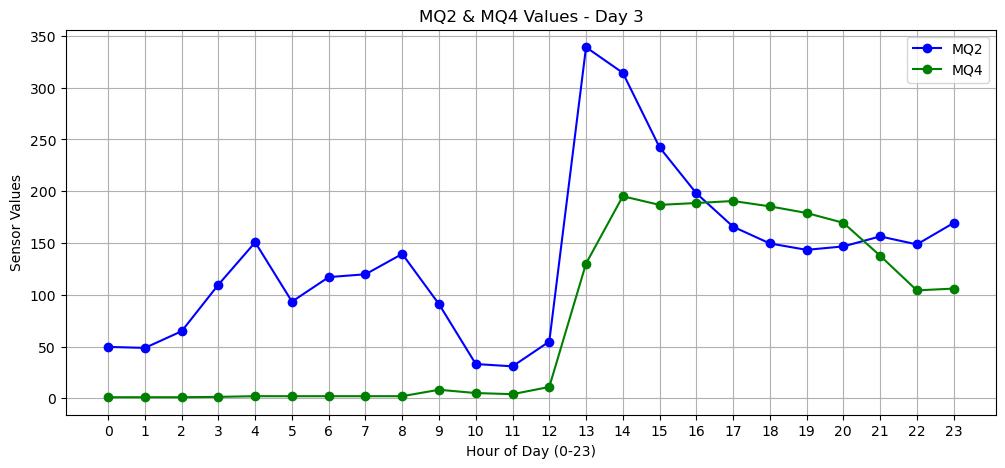

C:\Users\mbila\AppData\Local\Temp\ipykernel_28944\1434863366.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['HourOfDay'] = subset['HourIndex'] - start


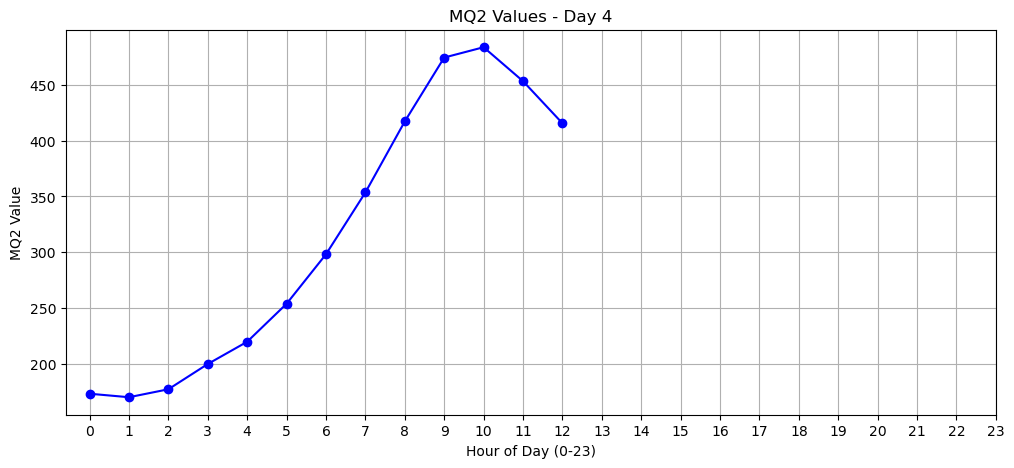

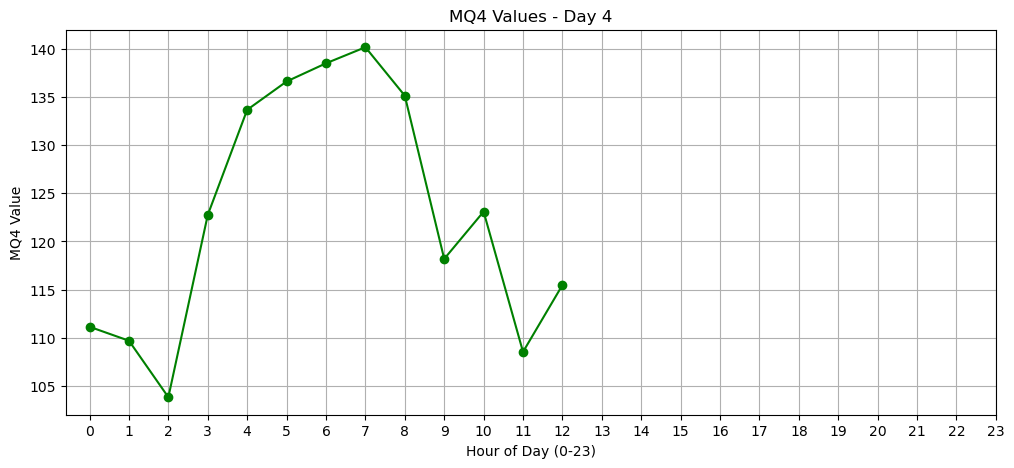

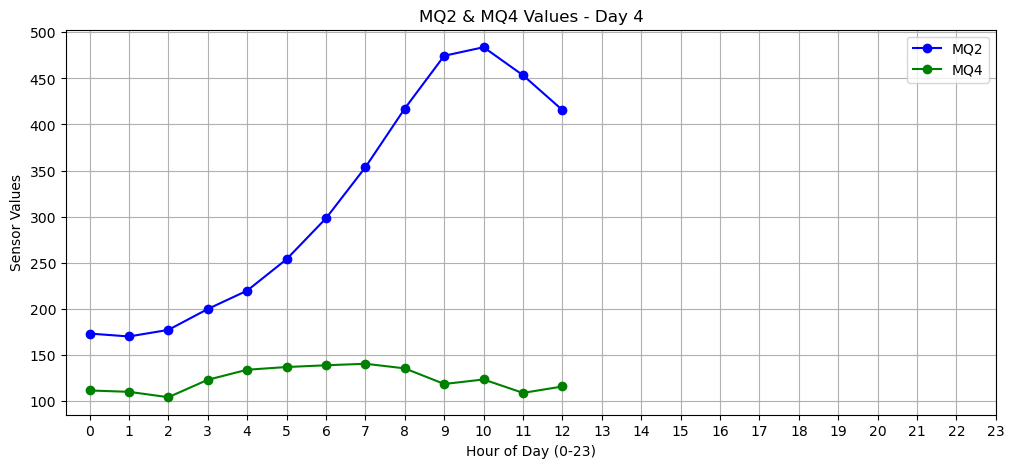

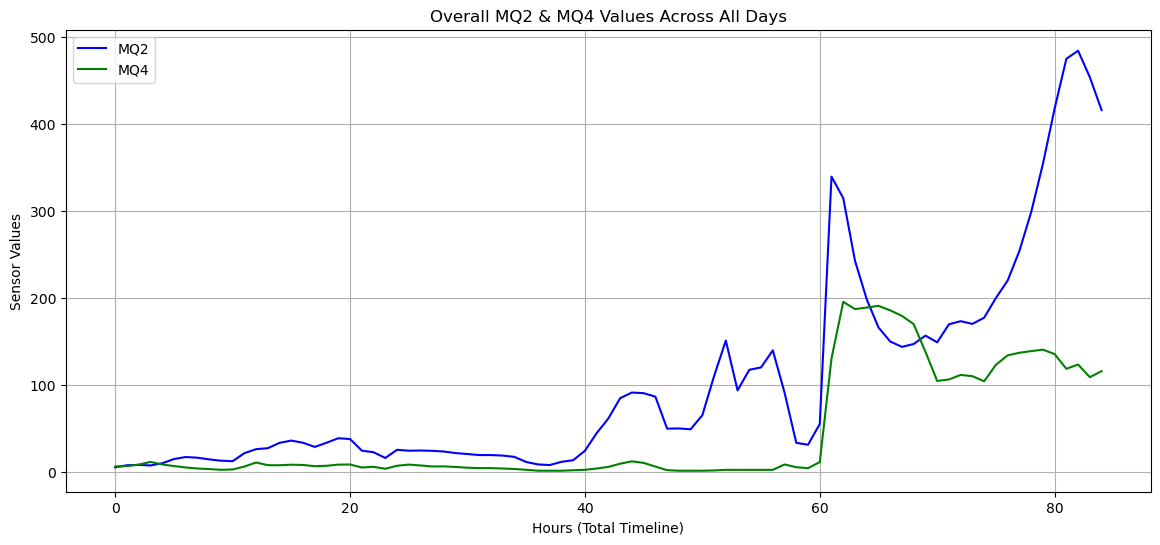

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File path
file_path = r"D:\ChipVista\Projects\decaying fruits\DATALOG-1.csv"

# Load dataset
df = pd.read_csv(file_path)

# Keep only useful columns
df = df[['mq2', 'mq4', 'Time']]

# --- Step 1: Detect hours by repetition of minutes cycle ---
hours = []
current_hour = 0
prev_minute = None

for t in df['Time']:
    try:
        mins, sec_milli = t.split(":")
        mins = int(mins)   # minute part
    except:
        mins = None
    
    # If minute value drops (e.g., from 59 → 0) => next hour
    if prev_minute is not None and mins is not None and mins < prev_minute:
        current_hour += 1
    
    hours.append(current_hour)
    prev_minute = mins

df['HourIndex'] = hours

# --- Step 2: Group by each hour (take mean values to represent that hour) ---
hourly_data = df.groupby('HourIndex')[['mq2','mq4']].mean().reset_index()

# --- Step 3: Split into days (24 hours each) ---
num_days = int(np.ceil(hourly_data['HourIndex'].max() / 24))

for day in range(num_days):
    start = day * 24
    end = (day + 1) * 24
    subset = hourly_data[(hourly_data['HourIndex'] >= start) & (hourly_data['HourIndex'] < end)]
    
    # Shift hour index to 0-23
    subset['HourOfDay'] = subset['HourIndex'] - start
    
    # Plot MQ2
    plt.figure(figsize=(12, 5))
    plt.plot(subset['HourOfDay'], subset['mq2'], marker='o', color='blue')
    plt.title(f"MQ2 Values - Day {day+1}")
    plt.xlabel("Hour of Day (0-23)")
    plt.ylabel("MQ2 Value")
    plt.xticks(range(24))
    plt.grid(True)
    plt.show()
    
    # Plot MQ4
    plt.figure(figsize=(12, 5))
    plt.plot(subset['HourOfDay'], subset['mq4'], marker='o', color='green')
    plt.title(f"MQ4 Values - Day {day+1}")
    plt.xlabel("Hour of Day (0-23)")
    plt.ylabel("MQ4 Value")
    plt.xticks(range(24))
    plt.grid(True)
    plt.show()
    
    # Plot merged
    plt.figure(figsize=(12, 5))
    plt.plot(subset['HourOfDay'], subset['mq2'], marker='o', label='MQ2', color='blue')
    plt.plot(subset['HourOfDay'], subset['mq4'], marker='o', label='MQ4', color='green')
    plt.title(f"MQ2 & MQ4 Values - Day {day+1}")
    plt.xlabel("Hour of Day (0-23)")
    plt.ylabel("Sensor Values")
    plt.xticks(range(24))
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Step 4: Final Overall Graph (all days together) ---
plt.figure(figsize=(14,6))
plt.plot(hourly_data['HourIndex'], hourly_data['mq2'], label='MQ2', color='blue')
plt.plot(hourly_data['HourIndex'], hourly_data['mq4'], label='MQ4', color='green')
plt.title("Overall MQ2 & MQ4 Values Across All Days")
plt.xlabel("Hours (Total Timeline)")
plt.ylabel("Sensor Values")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# File path
file_path = r"D:\ChipVista\Projects\decaying fruits\DATALOG-1.csv"
save_folder = r"D:\ChipVista\Projects\decaying fruits"

# Load dataset
df = pd.read_csv(file_path)

# Keep only useful columns
df = df[['mq2', 'mq4', 'Time']]

# --- Step 1: Detect hours by repetition of minutes cycle ---
hours = []
current_hour = 0
prev_minute = None

for t in df['Time']:
    try:
        mins, sec_milli = t.split(":")
        mins = int(mins)   # minute part
    except:
        mins = None
    
    # If minute value drops (e.g., from 59 → 0) => next hour
    if prev_minute is not None and mins is not None and mins < prev_minute:
        current_hour += 1
    
    hours.append(current_hour)
    prev_minute = mins

df['HourIndex'] = hours

# --- Step 2: Group by each hour (mean values) ---
hourly_data = df.groupby('HourIndex')[['mq2','mq4']].mean().reset_index()

# --- Step 3: Split into days (24 hours each) ---
num_days = int(np.ceil(hourly_data['HourIndex'].max() / 24))

for day in range(num_days):
    start = day * 24
    end = (day + 1) * 24
    subset = hourly_data[(hourly_data['HourIndex'] >= start) & (hourly_data['HourIndex'] < end)]
    
    # Shift hour index to 0-23
    subset['HourOfDay'] = subset['HourIndex'] - start
    
    # Plot MQ2
    plt.figure(figsize=(12, 5))
    plt.plot(subset['HourOfDay'], subset['mq2'], marker='o', color='blue')
    plt.title(f"MQ2 Values - Day {day+1}")
    plt.xlabel("Hour of Day (0-23)")
    plt.ylabel("MQ2 Value")
    plt.xticks(range(24))
    plt.grid(True)
    plt.savefig(os.path.join(save_folder, f"Day{day+1}_MQ2.png"))
    plt.close()
    
    # Plot MQ4
    plt.figure(figsize=(12, 5))
    plt.plot(subset['HourOfDay'], subset['mq4'], marker='o', color='green')
    plt.title(f"MQ4 Values - Day {day+1}")
    plt.xlabel("Hour of Day (0-23)")
    plt.ylabel("MQ4 Value")
    plt.xticks(range(24))
    plt.grid(True)
    plt.savefig(os.path.join(save_folder, f"Day{day+1}_MQ4.png"))
    plt.close()
    
    # Plot merged
    plt.figure(figsize=(12, 5))
    plt.plot(subset['HourOfDay'], subset['mq2'], marker='o', label='MQ2', color='blue')
    plt.plot(subset['HourOfDay'], subset['mq4'], marker='o', label='MQ4', color='green')
    plt.title(f"MQ2 & MQ4 Values - Day {day+1}")
    plt.xlabel("Hour of Day (0-23)")
    plt.ylabel("Sensor Values")
    plt.xticks(range(24))
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_folder, f"Day{day+1}_Merged.png"))
    plt.close()

# --- Step 4: Final Overall Graph (all days together) ---
plt.figure(figsize=(14,6))
plt.plot(hourly_data['HourIndex'], hourly_data['mq2'], label='MQ2', color='blue')
plt.plot(hourly_data['HourIndex'], hourly_data['mq4'], label='MQ4', color='green')
plt.title("Overall MQ2 & MQ4 Values Across All Days")
plt.xlabel("Hours (Total Timeline)")
plt.ylabel("Sensor Values")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_folder, "Overall_MQ2_MQ4.png"))
plt.close()


C:\Users\mbila\AppData\Local\Temp\ipykernel_28944\1200973997.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['HourOfDay'] = subset['HourIndex'] - start
C:\Users\mbila\AppData\Local\Temp\ipykernel_28944\1200973997.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['HourOfDay'] = subset['HourIndex'] - start
C:\Users\mbila\AppData\Local\Temp\ipykernel_28944\1200973997.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# --- File paths ---
file_path = r"D:\ChipVista\Projects\decaying fruits\DATALOG-1.csv"
save_folder = r"D:\ChipVista\Projects\decaying fruits"

# --- Load dataset ---
df = pd.read_csv(file_path)

# Keep only needed columns
df = df[['mq2', 'mq4', 'Time']]

# --- Step 1: Detect hours by repetition of minutes cycle ---
hours = []
current_hour = 0
prev_minute = None

for t in df['Time']:
    try:
        mins, sec_milli = t.split(":")
        mins = int(mins)
    except:
        mins = None
    
    # Detect new hour when minutes reset (e.g. 59 -> 0)
    if prev_minute is not None and mins is not None and mins < prev_minute:
        current_hour += 1
    
    hours.append(current_hour)
    prev_minute = mins

df['HourIndex'] = hours

# --- Step 2: Group by each hour (mean values) ---
hourly_data = df.groupby('HourIndex')[['mq2','mq4']].mean().reset_index()

# --- Step 3: Split into days (24 hours each) ---
num_days = int(np.ceil(hourly_data['HourIndex'].max() / 24))

for day in range(num_days):
    start = day * 24
    end = (day + 1) * 24
    subset = hourly_data[(hourly_data['HourIndex'] >= start) & (hourly_data['HourIndex'] < end)]
    
    # Shift hour index to 0–23
    subset['HourOfDay'] = subset['HourIndex'] - start

    # --- Generate interpolated half-hour points (0.5, 1.5, etc.) ---
    half_hours = np.arange(0.5, 24, 1)
    mq2_half = np.interp(half_hours, subset['HourOfDay'], subset['mq2'])
    mq4_half = np.interp(half_hours, subset['HourOfDay'], subset['mq4'])

    # --- Tick settings ---
    hour_ticks = np.arange(0, 24, 1)
    half_hour_ticks = np.arange(0.5, 24, 1)

    # --- MQ2 Plot ---
    plt.figure(figsize=(12, 5))
    plt.plot(subset['HourOfDay'], subset['mq2'], marker='o', color='blue')
    plt.plot(half_hours, mq2_half, 'o', color='skyblue')  # half-hour dots
    plt.title(f"MQ2 Values - Day {day+1}")
    plt.xlabel("Hour of Day (0–23)")
    plt.ylabel("MQ2 Value")

    # Add value labels on each main hour and half-hour
    for x, y in zip(subset['HourOfDay'], subset['mq2']):
        plt.text(x, y + 0.5, f"{y:.1f}", ha='center', va='bottom', fontsize=8, color='blue')
    for x, y in zip(half_hours, mq2_half):
        plt.text(x, y - 0.8, f"{y:.1f}", ha='center', va='top', fontsize=7, color='gray')

    # Axis formatting
    plt.xticks(hour_ticks)
    plt.gca().set_xticks(half_hour_ticks, minor=True)
    plt.tick_params(axis='x', which='major', length=8, width=1.2)
    plt.tick_params(axis='x', which='minor', length=4, color='gray')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    plt.savefig(os.path.join(save_folder, f"Day{day+1}_MQ2.png"))
    plt.close()

    # --- MQ4 Plot ---
    plt.figure(figsize=(12, 5))
    plt.plot(subset['HourOfDay'], subset['mq4'], marker='o', color='green')
    plt.plot(half_hours, mq4_half, 'o', color='lightgreen')  # half-hour dots
    plt.title(f"MQ4 Values - Day {day+1}")
    plt.xlabel("Hour of Day (0–23)")
    plt.ylabel("MQ4 Value")

    # Add value labels on each main hour and half-hour
    for x, y in zip(subset['HourOfDay'], subset['mq4']):
        plt.text(x, y + 0.5, f"{y:.1f}", ha='center', va='bottom', fontsize=8, color='green')
    for x, y in zip(half_hours, mq4_half):
        plt.text(x, y - 0.8, f"{y:.1f}", ha='center', va='top', fontsize=7, color='gray')

    plt.xticks(hour_ticks)
    plt.gca().set_xticks(half_hour_ticks, minor=True)
    plt.tick_params(axis='x', which='major', length=8, width=1.2)
    plt.tick_params(axis='x', which='minor', length=4, color='gray')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    plt.savefig(os.path.join(save_folder, f"Day{day+1}_MQ4.png"))
    plt.close()

    # --- Merged MQ2 & MQ4 Plot ---
    plt.figure(figsize=(12, 5))
    plt.plot(subset['HourOfDay'], subset['mq2'], marker='o', label='MQ2', color='blue')
    plt.plot(subset['HourOfDay'], subset['mq4'], marker='o', label='MQ4', color='green')
    plt.plot(half_hours, mq2_half, 'o', color='skyblue')   # MQ2 half-hour
    plt.plot(half_hours, mq4_half, 'o', color='lightgreen')  # MQ4 half-hour
    plt.title(f"MQ2 & MQ4 Values - Day {day+1}")
    plt.xlabel("Hour of Day (0–23)")
    plt.ylabel("Sensor Values")
    plt.legend()

    # Add value labels for full and half-hour points
    for x, y in zip(subset['HourOfDay'], subset['mq2']):
        plt.text(x, y + 0.5, f"{y:.1f}", ha='center', va='bottom', fontsize=8, color='blue')
    for x, y in zip(subset['HourOfDay'], subset['mq4']):
        plt.text(x, y - 0.5, f"{y:.1f}", ha='center', va='top', fontsize=8, color='green')

    for x, y in zip(half_hours, mq2_half):
        plt.text(x, y + 0.5, f"{y:.1f}", ha='center', va='bottom', fontsize=7, color='skyblue')
    for x, y in zip(half_hours, mq4_half):
        plt.text(x, y - 0.5, f"{y:.1f}", ha='center', va='top', fontsize=7, color='lightgreen')

    plt.xticks(hour_ticks)
    plt.gca().set_xticks(half_hour_ticks, minor=True)
    plt.tick_params(axis='x', which='major', length=8, width=1.2)
    plt.tick_params(axis='x', which='minor', length=4, color='gray')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    plt.savefig(os.path.join(save_folder, f"Day{day+1}_Merged.png"))
    plt.close()

# --- Step 4: Overall Graph (no labels, clean look) ---
plt.figure(figsize=(14,6))
plt.plot(hourly_data['HourIndex'], hourly_data['mq2'], label='MQ2', color='blue', marker='o')
plt.plot(hourly_data['HourIndex'], hourly_data['mq4'], label='MQ4', color='green', marker='o')
plt.title("Overall MQ2 & MQ4 Values Across All Days")
plt.xlabel("Hours (Total Timeline)")
plt.ylabel("Sensor Values")
plt.legend()

# Add ticks only
total_hours = int(hourly_data['HourIndex'].max()) + 1
hour_ticks = np.arange(0, total_hours, 1)
half_hour_ticks = np.arange(0.5, total_hours, 1)
plt.xticks(hour_ticks)
plt.gca().set_xticks(half_hour_ticks, minor=True)
plt.tick_params(axis='x', which='major', length=8, width=1.2)
plt.tick_params(axis='x', which='minor', length=4, color='gray')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.savefig(os.path.join(save_folder, "Overall_MQ2_MQ4.png"))
plt.close()

print("✅ All graphs saved with half-hour dots and value labels (except clean overall graph).")


C:\Users\mbila\AppData\Local\Temp\ipykernel_28572\1114959517.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['HourOfDay'] = subset['HourIndex'] - start
C:\Users\mbila\AppData\Local\Temp\ipykernel_28572\1114959517.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['HourOfDay'] = subset['HourIndex'] - start
C:\Users\mbila\AppData\Local\Temp\ipykernel_28572\1114959517.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

✅ All graphs saved with half-hour dots and value labels (except clean overall graph).


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# ------------ Paths ------------
file_path = r"D:\ChipVista\Projects\decaying fruits\DATALOG-1.csv"
save_folder = r"D:\ChipVista\Projects\decaying fruits"

# ------------ Config ------------
START_DATETIME = "2025-09-30 00:00:00"    # ✅ new start
END_DATETIME   = "2025-10-03 12:00:00"    # ✅ new end
TIME_FORMAT = "%Y-%m-%d %H:%M"

# ------------ Load data ------------
df = pd.read_csv(file_path)
df = df[['mq2', 'mq4', 'Time']]

# --- Step 1: Detect hours by minute reset ---
hours = []
current_hour = 0
prev_minute = None

for t in df['Time']:
    try:
        mins, sec_milli = t.split(":")
        mins = int(mins)
    except:
        mins = None

    if prev_minute is not None and mins is not None and mins < prev_minute:
        current_hour += 1
    hours.append(current_hour)
    prev_minute = mins

df['HourIndex'] = hours

# --- Step 2: Group hourly means ---
hourly_data = df.groupby('HourIndex')[['mq2', 'mq4']].mean().reset_index()

# Map hours to real datetimes starting at START_DATETIME
start_dt = pd.to_datetime(START_DATETIME)
hourly_data['dt'] = start_dt + pd.to_timedelta(hourly_data['HourIndex'], unit='h')

# --- Step 3: Define fixed tick positions (every 12 hours) ---
tick_positions = pd.date_range(start=start_dt, end=pd.to_datetime(END_DATETIME), freq='12H')

# --- Step 4: Plot helper ---
def plot_series(dfh, column, color, title, filename, y_label):
    plt.figure(figsize=(14, 6))
    plt.plot(dfh['dt'], dfh[column], marker='o', color=color)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(y_label)
    plt.grid(True)

    ax = plt.gca()
    ax.set_xticks(tick_positions)
    ax.xaxis.set_major_formatter(mdates.DateFormatter(TIME_FORMAT))
    plt.xticks(rotation=30, ha='right')

    # ✅ Force x-axis limits from start to end
    ax.set_xlim(pd.to_datetime(START_DATETIME), pd.to_datetime(END_DATETIME))

    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, filename))
    plt.close()

# --- Plot MQ2 ---
plot_series(
    hourly_data,
    column='mq2',
    color='blue',
    title="Overall MQ2 Values (Hourly Mean)\n(2025-09-30 00:00 → 2025-10-03 12:00)",
    filename="Overall_MQ2.png",
    y_label="MQ2 Value"
)

# --- Plot MQ4 ---
plot_series(
    hourly_data,
    column='mq4',
    color='green',
    title="Overall MQ4 Values (Hourly Mean)\n(2025-09-30 00:00 → 2025-10-03 12:00)",
    filename="Overall_MQ4.png",
    y_label="MQ4 Value"
)


C:\Users\mbila\AppData\Local\Temp\ipykernel_28572\3960407742.py:46: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  tick_positions = pd.date_range(start=start_dt, end=pd.to_datetime(END_DATETIME), freq='12H')


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# ------------ Paths ------------
file_path = r"D:\ChipVista\Projects\decaying fruits\DATALOG-1.csv"
save_folder = r"D:\ChipVista\Projects\decaying fruits"

# ------------ Config ------------
START_DATETIME = "2025-09-30 00:00:00"
END_DATETIME   = "2025-10-03 12:00:00"
TIME_FORMAT = "%Y-%m-%d %H:%M"

# ------------ Load data ------------
df = pd.read_csv(file_path)
df = df[['mq2', 'mq4', 'Time']]

# --- Step 1: Detect hours by minute reset ---
hours = []
current_hour = 0
prev_minute = None
for t in df['Time']:
    try:
        mins, sec_milli = t.split(":")
        mins = int(mins)
    except:
        mins = None
    if prev_minute is not None and mins is not None and mins < prev_minute:
        current_hour += 1
    hours.append(current_hour)
    prev_minute = mins

df['HourIndex'] = hours

# --- Step 2: Hourly mean ---
hourly_data = df.groupby('HourIndex')[['mq2','mq4']].mean().reset_index()

start_dt = pd.to_datetime(START_DATETIME)
end_dt = pd.to_datetime(END_DATETIME)
hourly_data['dt'] = start_dt + pd.to_timedelta(hourly_data['HourIndex'], unit='h')

# --- Step 3: Tick positions ---
tick_positions = pd.date_range(start=start_dt, end=end_dt, freq='12H')

# --- Step 4: Plot with margin ---
def plot_series(dfh, column, color, title, filename, y_label):
    plt.figure(figsize=(14, 6))
    plt.plot(dfh['dt'], dfh[column], marker='o', color=color)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(y_label)
    plt.grid(True)

    ax = plt.gca()
    ax.set_xticks(tick_positions)
    ax.xaxis.set_major_formatter(mdates.DateFormatter(TIME_FORMAT))
    plt.xticks(rotation=30, ha='right')

    # ✅ Add 5% margin on both sides of the x-axis
    total_range = end_dt - start_dt
    margin = total_range * 0.05
    ax.set_xlim(start_dt - margin, end_dt + margin)

    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, filename))
    plt.close()

# --- MQ2 Plot ---
plot_series(
    hourly_data,
    column='mq2',
    color='blue',
    title="Overall MQ2 Values (Hourly Mean)\n(2025-09-30 00:00 → 2025-10-03 12:00)",
    filename="Overall_MQ2.png",
    y_label="MQ2 Value"
)

# --- MQ4 Plot ---
plot_series(
    hourly_data,
    column='mq4',
    color='green',
    title="Overall MQ4 Values (Hourly Mean)\n(2025-09-30 00:00 → 2025-10-03 12:00)",
    filename="Overall_MQ4.png",
    y_label="MQ4 Value"
)


C:\Users\mbila\AppData\Local\Temp\ipykernel_28572\1840239052.py:44: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  tick_positions = pd.date_range(start=start_dt, end=end_dt, freq='12H')
